In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install geopandas rioxarray rasterstats netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [ ]:
import os
import glob
import time
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray
from rasterstats import zonal_stats
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import warnings

# Suppress minor spatial warnings for cleaner console output
warnings.filterwarnings("ignore", category=UserWarning)

# ==================================================
# 1. PATHS & CONFIGURATION
# ==================================================

WATERSHED_FILE = r"/content/drive/MyDrive/Drought Prediction Project/WaterSheds/Fixed_Cauvery_WaterSheds.gpkg"
RAINFALL_FOLDER = r"/content/drive/MyDrive/Drought Prediction Project/Rainfall"
OUTPUT_FILE = r"/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Daily_Rainfall_1981_2025.csv"

# Force Colab to use both of its available CPU cores
MAX_WORKERS = 2

# ==================================================
# 2. PARALLEL WORKER FUNCTION
# ==================================================
def process_single_year(nc_file, watersheds_gdf):
    """
    Processes a single NetCDF file entirely in-memory.
    Returns a Pandas DataFrame of daily rainfall for all watersheds.
    """
    year_name = os.path.basename(nc_file).replace(".nc", "") # Extract year name for description
    daily_rows = []

    try:
        # Load the dataset
        ds = xr.open_dataset(nc_file)

        # Ensure dimensions are correctly oriented for rioxarray
        rainfall = ds["RAINFALL"].sortby("LATITUDE", ascending=False)
        rainfall = rainfall.rio.set_spatial_dims(x_dim="LONGITUDE", y_dim="LATITUDE")
        rainfall = rainfall.rio.write_crs("EPSG:4326")

        total_days = len(ds.TIME)

        # Add tqdm to the inner loop for daily progress
        for t in tqdm(range(total_days), desc=f"  Processing {year_name} (days)", leave=False):
            date = pd.to_datetime(ds.TIME.values[t])
            raster = rainfall.isel(TIME=t)

            # --- IN-MEMORY OPTIMIZATION ---s
            # Extract raw numpy array and spatial transform mapping
            array = raster.values
            transform = raster.rio.transform()

            # Compute zonal stats directly from RAM
            stats = zonal_stats(
                watersheds_gdf,
                array,
                affine=transform,
                stats=["mean"],
                nodata=np.nan
            )

            for wid, stat in zip(watersheds_gdf["Watershed_ID"], stats):
                rainfall_value = stat["mean"]
                if rainfall_value is None or np.isnan(rainfall_value):
                    rainfall_value = 0.0

                daily_rows.append({
                    "Date": date.strftime("%d-%m-%Y"),
                    "Watershed_ID": wid,
                    "Rainfall_mm": round(rainfall_value, 4) # Rounding saves memory/disk space
                })

        ds.close()
        return pd.DataFrame(daily_rows), year_name, True

    except Exception as e:
        return None, year_name, str(e)

# ==================================================
# 3. MAIN EXECUTION (Protected for Windows Multiprocessing)
# ==================================================
if __name__ == "__main__":
    start_time = time.time()

    print("==================================================")
    print("INITIALIZING MULTI-CORE EXTRACTION PIPELINE")
    print("==================================================")

    # --- A. Load and Prepare Watersheds ---
    print("Loading geographic boundaries...")
    watersheds = gpd.read_file(WATERSHED_FILE)

    # Must be EPSG:4326 to overlay accurately on IMD NetCDF Grids
    watersheds = watersheds.to_crs("EPSG:4326")
    watersheds["Watershed_ID"] = range(1, len(watersheds) + 1)
    print(f"Watersheds Loaded: {len(watersheds)}")

    # --- B. Find NetCDF Files ---
    print("\nSearching for NetCDF rainfall data files...")
    nc_files = sorted(glob.glob(os.path.join(RAINFALL_FOLDER, "*.nc")))
    print(f"NetCDF Files Found: {len(nc_files)}")
    if len(nc_files) == 0:
        raise FileNotFoundError("No NetCDF files found in the specified folder.")

    # --- C. Remove Old Output ---
    if os.path.exists(OUTPUT_FILE):
        os.remove(OUTPUT_FILE)
        print("\nCleared previous output file to ensure fresh data generation.")

    # --- D. Execute Parallel Processing ---
    print(f"\nStarting parallel processing across {MAX_WORKERS} CPU cores...")

    all_yearly_dataframes = [] # List to collect DataFrames from each year

    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Submit all tasks to the processor pool
        future_to_file = {
            executor.submit(process_single_year, nc_file, watersheds): nc_file
            for nc_file in nc_files
        }

        # Use tqdm to show a progress bar as years are completed
        for future in tqdm(as_completed(future_to_file), total=len(nc_files), desc="Overall Year Progress"):
            df_year, year_name, status = future.result()

            if status is True:
                all_yearly_dataframes.append(df_year)
            else:
                print(f"\nERROR processing {year_name}: {status}")

    # --- E. Concatenate and Save All Results ---
    print("\nCombining all processed yearly data and saving to CSV...")
    if all_yearly_dataframes:
        final_df = pd.concat(all_yearly_dataframes, ignore_index=True)
        final_df.to_csv(OUTPUT_FILE, index=False)
        print(f"All data successfully saved to {OUTPUT_FILE}")
    else:
        final_df = pd.DataFrame(columns=["Date", "Watershed_ID", "Rainfall_mm"]) # Create an empty DF if no data
        print("No data was successfully processed to save.")

    # ==================================================
    # 4. SUMMARY & VALIDATION
    # ==================================================
    elapsed = (time.time() - start_time) / 60

    print("\n==================================================")
    print("EXTRACTION COMPLETED SUCCESSFULLY")
    print("==================================================")
    print(f"Total Execution Time : {elapsed:.2f} minutes")

    print("\nValidating Output Architecture...")

    if not final_df.empty: # Check if final_df is not empty before processing
        # Convert dates to check min/max properly
        final_df["Date"] = pd.to_datetime(final_df["Date"], format="%d-%m-%Y")

        print(f"Total Daily Records : {len(final_df):,}")
        print(f"Unique Watersheds   : {final_df['Watershed_ID'].nunique()}")
        print(f"First Record        : {final_df['Date'].min().strftime('%d-%m-%Y')}")
        print(f"Last Record         : {final_df['Date'].max().strftime('%d-%m-%Y')}")

        print("\nRainfall Statistics Verification:")
        print(final_df["Rainfall_mm"].describe())
    else:
        print("No records found in the final output for validation.")

INITIALIZING MULTI-CORE EXTRACTION PIPELINE
Loading geographic boundaries...
Watersheds Loaded: 132

Searching for NetCDF rainfall data files...
NetCDF Files Found: 45

Cleared previous output file to ensure fresh data generation.

Starting parallel processing across 2 CPU cores...


Overall Year Progress: 100%|██████████| 45/45 [3:23:55<00:00, 271.90s/it]



Combining all processed yearly data and saving to CSV...
All data successfully saved to /content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Daily_Rainfall_1981_2025.csv

EXTRACTION COMPLETED SUCCESSFULLY
Total Execution Time : 204.00 minutes

Validating Output Architecture...
Total Daily Records : 2,169,552
Unique Watersheds   : 132
First Record        : 01-01-1981
Last Record         : 31-12-2025

Rainfall Statistics Verification:
count    2.169552e+06
mean     1.964779e+00
std      7.585237e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.135667e+02
Name: Rainfall_mm, dtype: float64


In [ ]:
import pandas as pd
import time
import os

# ==================================================
# 1. PATHS
# ==================================================
# Update paths if your Colab folder structure differs
INPUT_FILE = r"/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Daily_Rainfall_1981_2025.csv"
OUTPUT_FILE = r"/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Monthly_Rainfall_1981_2025.csv"

start_time = time.time()

print("==================================================")
print("INITIALIZING TEMPORAL AGGREGATION PIPELINE")
print("==================================================")

# --- A. Load Daily Data ---
print("Loading daily rainfall data (This may take a minute for 45 years of data)...")
df = pd.read_csv(INPUT_FILE)

# Ensure the Date column is a proper datetime object
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# --- B. Group and Aggregate ---
print("Aggregating daily rainfall into monthly totals...")

# Extract Year and Month to group by
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# Group by Watershed and Year-Month, then sum the rainfall
monthly_df = df.groupby(['Watershed_ID', 'Year', 'Month'])['Rainfall_mm'].sum().reset_index()

# Round the monthly totals to 4 decimal places to keep the dataset lightweight
monthly_df['Rainfall_mm'] = monthly_df['Rainfall_mm'].round(4)

# --- C. Format for SPI Script ---
print("Standardizing temporal schema for compute_spi.py...")

# Reconstruct the Date to the 1st of every month (e.g., 01-06-1981)
monthly_df['Date'] = pd.to_datetime(dict(year=monthly_df['Year'], month=monthly_df['Month'], day=1))

# Convert back to the %d-%m-%Y string format your SPI script expects
monthly_df['Date'] = monthly_df['Date'].dt.strftime('%d-%m-%Y')

# Sort chronologically by Watershed, then Date
monthly_df = monthly_df.sort_values(['Watershed_ID', 'Year', 'Month']).reset_index(drop=True)

# Drop the temporary Year and Month columns to match your exact original schema
monthly_df = monthly_df[['Watershed_ID', 'Date', 'Rainfall_mm']]

# --- D. Export ---
monthly_df.to_csv(OUTPUT_FILE, index=False)

# ==================================================
# 2. SUMMARY & VALIDATION
# ==================================================
elapsed = (time.time() - start_time) / 60

print("\n==================================================")
print("AGGREGATION COMPLETED SUCCESSFULLY")
print("==================================================")
print(f"Total Execution Time  : {elapsed:.2f} minutes")
print(f"Total Monthly Records : {len(monthly_df):,}")
print(f"Expected Records      : 132 watersheds * 45 years * 12 months = {132 * 45 * 12:,}")

print("\nSample Output (First 5 Rows):")
print(monthly_df.head())

INITIALIZING TEMPORAL AGGREGATION PIPELINE
Loading daily rainfall data (This may take a minute for 45 years of data)...
Aggregating daily rainfall into monthly totals...
Standardizing temporal schema for compute_spi.py...

AGGREGATION COMPLETED SUCCESSFULLY
Total Execution Time  : 0.04 minutes
Total Monthly Records : 71,280
Expected Records      : 132 watersheds * 45 years * 12 months = 71,280

Sample Output (First 5 Rows):
   Watershed_ID        Date  Rainfall_mm
0             1  01-01-1981       0.0000
1             1  01-02-1981       0.0000
2             1  01-03-1981      19.1852
3             1  01-04-1981       4.1539
4             1  01-05-1981      91.7584


In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
from scipy.stats import gamma, norm
from tqdm import tqdm

# Suppress scipy fitting warnings for ultra-dry months
warnings.filterwarnings("ignore")

# ==================================================
# 1. PATHS & CONFIGURATION
# ==================================================
INPUT_FILE = r"/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Monthly_Rainfall_1981_2025.csv"
OUTPUT_FILE = r"/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_SPI_1981_2025.csv"

# WMO strict baseline definition
BASELINE_START = 1981
BASELINE_END = 2010

start_time = time.time()

print("==================================================")
print("INITIALIZING WMO-COMPLIANT SPI PIPELINE")
print("==================================================")

# --- A. Load & Prep Data ---
print("Loading monthly rainfall data...")
df = pd.read_csv(INPUT_FILE)
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Ensure chronological sorting for rolling sums
df = df.sort_values(["Watershed_ID", "Date"]).reset_index(drop=True)

def accumulated(series, scale):
    """Calculates the rolling accumulation for SPI-n timescales."""
    return series.rolling(scale, min_periods=scale).sum()

# ==================================================
# 2. PHASE 1: THE CALIBRATION ENGINE (FIT)
# ==================================================
def fit_gamma_parameters(historical_series):
    """
    Computes WMO Thom's Estimator parameters using ONLY the baseline period.
    Returns: shape (alpha), scale (beta), zero-probability (q).
    """
    valid_data = historical_series.dropna()
    if len(valid_data) == 0:
        return np.nan, np.nan, np.nan

    n_zeros = (valid_data == 0).sum()
    q = n_zeros / len(valid_data)

    non_zero_data = valid_data[valid_data > 0]

    if len(non_zero_data) >= 5 and non_zero_data.nunique() >= 2:
        try:
            # --- WMO Thom's Estimator Core Logic ---
            mean_val = non_zero_data.mean()
            A = np.log(mean_val) - np.mean(np.log(non_zero_data))

            if A > 0:
                shape = (1.0 + np.sqrt(1.0 + (4.0 * A) / 3.0)) / (4.0 * A)
                scale = mean_val / shape
                return shape, scale, q
        except Exception:
            pass # Fall through to Method of Moments

        # Fallback to simple Method of Moments
        mean_val = non_zero_data.mean()
        var_val = non_zero_data.var(ddof=1)
        if var_val > 0:
            shape = (mean_val ** 2) / var_val
            scale = var_val / mean_val
            return shape, scale, q

    return np.nan, np.nan, q

# ==================================================
# 3. PHASE 2: THE TRANSFORMATION ENGINE (APPLY)
# ==================================================
def apply_gamma_transformation(full_series, shape, scale, q):
    """
    Applies the fixed baseline parameters to the entire timeline.
    """
    h_x = pd.Series(np.nan, index=full_series.index)

    # 1. Assign zero-rainfall probabilities
    zero_mask = full_series == 0
    h_x.loc[zero_mask] = q/2.0

    # 2. Compute Gamma CDF for non-zero rainfall
    non_zero_mask = full_series > 0
    if non_zero_mask.sum() > 0:
        if not np.isnan(shape) and not np.isnan(scale):
            g_x = gamma.cdf(full_series[non_zero_mask], a=shape, loc=0, scale=scale)
            h_x.loc[non_zero_mask] = q + (1 - q) * g_x
        else:
            # Fallback for uncomputable highly-sparse months
            h_x.loc[non_zero_mask] = q + (1 - q) * 0.5

    # 3. Inverse Standard Normal Transformation (with infinite bound clipping)
    spi = pd.Series(np.nan, index=full_series.index)
    h_x_clean = h_x.dropna()

    if len(h_x_clean) > 0:
        h_x_clipped = np.clip(h_x_clean, 1e-6, 1 - 1e-6)
        spi.loc[h_x_clipped.index] = norm.ppf(h_x_clipped)

    return spi

# ==================================================
# 4. EXECUTE SPATIAL-TEMPORAL LOOP
# ==================================================
results = []
scales = [3, 6, 12] # Generating SPI-3 (Agricultural), SPI-6, and SPI-12 (Hydrological)

for ws in tqdm(df["Watershed_ID"].unique(), desc="Processing Watersheds"):
    ws_data = df[df["Watershed_ID"] == ws].copy()

    for scale in scales:
        rf_col = f"RF{scale}"
        spi_col = f"SPI{scale}"

        # Calculate Rolling Accumulation
        ws_data[rf_col] = accumulated(ws_data["Rainfall_mm"], scale)
        ws_data[spi_col] = np.nan

        for m in range(1, 13):
            month_mask = ws_data["Month"] == m

            # --- ISOLATE THE BASELINE (1981-2010) ---
            baseline_mask = month_mask & (ws_data["Year"] >= BASELINE_START) & (ws_data["Year"] <= BASELINE_END)

            historical_series = ws_data.loc[baseline_mask, rf_col]
            full_series = ws_data.loc[month_mask, rf_col]

            # --- PHASE 1: FIT ON BASELINE ---
            shape, scale_val, q = fit_gamma_parameters(historical_series)

            # --- PHASE 2: APPLY TO TIMELINE ---
            spi_values = apply_gamma_transformation(full_series, shape, scale_val, q)
            ws_data.loc[month_mask, spi_col] = spi_values

    results.append(ws_data)

# ==================================================
# 5. EXPORT & VALIDATE
# ==================================================
final_df = pd.concat(results, ignore_index=True)

# Keep the dataframe clean
columns_to_keep = ["Watershed_ID", "Date", "Rainfall_mm", "SPI3", "SPI6", "SPI12"]
final_df = final_df[columns_to_keep]

# Export
final_df.to_csv(OUTPUT_FILE, index=False, date_format="%d-%m-%Y")

elapsed = (time.time() - start_time) / 60

print("\n==================================================")
print("SPI COMPUTATION COMPLETED DIFFERENTIALLY")
print("==================================================")
print(f"Total Execution Time : {elapsed:.2f} minutes")
print(f"Calibration Baseline : {BASELINE_START} - {BASELINE_END}")

print("\nGlobal Descriptive Statistics (Checking for extreme anomalies):")
print(final_df[["SPI3", "SPI6", "SPI12"]].describe().round(3))

print("\nSample Output (End of Timeline):")
print(final_df.tail(5))

INITIALIZING WMO-COMPLIANT SPI PIPELINE
Loading monthly rainfall data...


Processing Watersheds: 100%|██████████| 132/132 [00:22<00:00,  5.80it/s]



SPI COMPUTATION COMPLETED DIFFERENTIALLY
Total Execution Time : 0.40 minutes
Calibration Baseline : 1981 - 2010

Global Descriptive Statistics (Checking for extreme anomalies):
            SPI3       SPI6      SPI12
count  71016.000  70620.000  69828.000
mean       0.084      0.106      0.126
std        0.937      0.950      0.961
min       -4.753     -4.753     -4.753
25%       -0.311     -0.275     -0.218
50%        0.000      0.000      0.000
75%        0.545      0.570      0.588
max        4.753      4.753      4.753

Sample Output (End of Timeline):
       Watershed_ID       Date  Rainfall_mm      SPI3      SPI6     SPI12
71275           132 2025-08-01      74.8667 -0.151704  0.496679  0.470673
71276           132 2025-09-01     107.1856  0.154843  0.385285  0.602081
71277           132 2025-10-01     215.2720  0.551120  0.553011  0.593279
71278           132 2025-11-01      67.5069  0.312559  0.196211  0.527766
71279           132 2025-12-01      23.4611  0.225299  0.173272  0.

In [ ]:
!pip install geopandas

In [ ]:
import geopandas as gpd
import pandas as pd
import os

# ==================================================
# 1. DEFINE COLAB PATHS
# ==================================================
WATERSHED_FILE = "/content/drive/MyDrive/Drought Prediction Project/WaterSheds/Fixed_Cauvery_WaterSheds.gpkg"
OUTPUT_CSV = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Watershed_Centroids.csv"

print("==================================================")
print("INITIALIZING CENTROID EXTRACTION PIPELINE")
print("==================================================")

# --- A. Load Watershed Data ---
print("Loading watershed boundaries...")
gdf = gpd.read_file(WATERSHED_FILE)

# Ensure Watershed_ID exists; if not, generate it sequentially
if "Watershed_ID" not in gdf.columns:
    gdf["Watershed_ID"] = range(1, len(gdf) + 1)

print(f"Loaded {len(gdf)} watersheds.")

# --- B. Reproject to Metric CRS ---
# Projecting to EPSG:32643 (UTM Zone 43N) prevents area/distance distortion
print("Reprojecting to EPSG:32643 (UTM Zone 43N)...")
gdf = gdf.to_crs(epsg=32643)

# --- C. Extract Centroids ---
print("Extracting geometric centroids...")
centroids = gdf.geometry.centroid

# Extract X and Y coordinates
# Note: Because we are in a metric CRS, these are large UTM coordinate values, not standard Lat/Lon degrees.
gdf['Longitude_UTM'] = centroids.x
gdf['Latitude_UTM'] = centroids.y

# --- D. Format and Export ---
print("Formatting output feature space...")
# Isolate the exact columns needed for the GMM merge
columns_to_keep = ['Watershed_ID', 'Longitude_UTM', 'Latitude_UTM']
df_centroids = pd.DataFrame(gdf[columns_to_keep])

# Save to CSV
df_centroids.to_csv(OUTPUT_CSV, index=False)

print("\n==================================================")
print("EXTRACTION COMPLETED SUCCESSFULLY")
print("==================================================")
print(f"Saved to: {OUTPUT_CSV}")
print("\nSample Output (First 5 Rows):")
print(df_centroids.head())

INITIALIZING CENTROID EXTRACTION PIPELINE
Loading watershed boundaries...
Loaded 132 watersheds.
Reprojecting to EPSG:32643 (UTM Zone 43N)...
Extracting geometric centroids...
Formatting output feature space...

EXTRACTION COMPLETED SUCCESSFULLY
Saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Watershed_Centroids.csv

Sample Output (First 5 Rows):
   Watershed_ID  Longitude_UTM  Latitude_UTM
0             1  724699.582088  1.479627e+06
1             2  582639.102302  1.464896e+06
2             3  659904.640261  1.456437e+06
3             4  685122.886171  1.464864e+06
4             5  704403.080328  1.471265e+06


In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import os

# ==================================================
# 1. PATHS & CONFIGURATION
# ==================================================
SPI_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_SPI_1981_2025.csv"
CENTROIDS_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Watershed_Centroids.csv"
OUTPUT_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Regime_Clustered_Data.csv"

# As defined in your architecture, we are targeting 4 distinct regimes
N_REGIMES = 4

start_time = time.time()

print("==================================================")
print("INITIALIZING SPATIALLY-EXPLICIT GMM PIPELINE")
print("==================================================")

# --- A. Load and Merge Data ---
print("Loading SPI and Spatial datasets...")
spi_df = pd.read_csv(SPI_FILE)
centroids_df = pd.read_csv(CENTROIDS_FILE)

print("Fusing spatial coordinates with temporal drought indices...")
# Merge on Watershed_ID to append Latitude_UTM and Longitude_UTM to every monthly record
merged_df = pd.merge(spi_df, centroids_df, on="Watershed_ID", how="left")

# Drop any potential NaNs generated during merging to keep the GMM stable
clean_df = merged_df.dropna().copy()

# --- B. Feature Selection & Scaling ---
print("\nIsolating feature space and applying StandardScaler...")
# We select both the temporal drought indicators and the structural geographic anchors
features = ['SPI3', 'SPI6', 'SPI12', 'Longitude_UTM', 'Latitude_UTM']
X = clean_df[features]

# StandardScaler is mandatory here because SPI values range from roughly -4 to +4,
# while UTM metric coordinates range in the hundreds of thousands. Without scaling,
# the GMM will completely ignore the climate data.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- C. Train Gaussian Mixture Model ---
print(f"\nTraining Gaussian Mixture Model to discover {N_REGIMES} regimes...")
# We use a 'full' covariance matrix so the clusters can take on elliptical shapes,
# better capturing the complex, non-linear relationships between geography and rainfall.
gmm = GaussianMixture(
    n_components=N_REGIMES,
    covariance_type='full',
    random_state=42, # Set seed for reproducibility
    max_iter=300,
    n_init=5 # Run the algorithm 5 times with different initializations to find the best fit
)

# Fit the model and predict the regime for every single row
clean_df['Climate_Regime'] = gmm.fit_predict(X_scaled)

# Since GMM clusters are zero-indexed (0, 1, 2, 3), we shift them to 1-4 for easier reporting
clean_df['Climate_Regime'] = clean_df['Climate_Regime'] + 1

# Extract the probabilistic confidence of the model's choice
# This gives us the probability that a data point belongs to its assigned cluster
probabilities = gmm.predict_proba(X_scaled)
clean_df['Regime_Confidence'] = np.max(probabilities, axis=1)

# --- D. Export and Summary ---
print("\nExporting clustered dataset...")
clean_df.to_csv(OUTPUT_FILE, index=False)

elapsed = (time.time() - start_time) / 60

print("\n==================================================")
print("REGIME DISCOVERY COMPLETED SUCCESSFULLY")
print("==================================================")
print(f"Total Execution Time: {elapsed:.2f} minutes")
print(f"Total Records Processed: {len(clean_df):,}")

print("\nRegime Distribution (Number of months spent in each regime):")
print(clean_df['Climate_Regime'].value_counts().sort_index())

print("\nAverage Regime Confidence:")
print(f"{clean_df['Regime_Confidence'].mean() * 100:.2f}%")

print("\nSample Output (First 5 Rows):")
print(clean_df[['Watershed_ID', 'Date', 'SPI6', 'Longitude_UTM', 'Climate_Regime', 'Regime_Confidence']].head())

INITIALIZING SPATIALLY-EXPLICIT GMM PIPELINE
Loading SPI and Spatial datasets...
Fusing spatial coordinates with temporal drought indices...

Isolating feature space and applying StandardScaler...

Training Gaussian Mixture Model to discover 4 regimes...

Exporting clustered dataset...

REGIME DISCOVERY COMPLETED SUCCESSFULLY
Total Execution Time: 0.45 minutes
Total Records Processed: 69,828

Regime Distribution (Number of months spent in each regime):
Climate_Regime
1    13617
2     8774
3    17457
4    29980
Name: count, dtype: int64

Average Regime Confidence:
86.76%

Sample Output (First 5 Rows):
    Watershed_ID        Date      SPI6  Longitude_UTM  Climate_Regime  \
11             1  01-12-1981  0.518495  724699.582088               4   
12             1  01-01-1982  0.843494  724699.582088               4   
13             1  01-02-1982  0.605002  724699.582088               4   
14             1  01-03-1982 -0.172845  724699.582088               4   
15             1  01-04-198

In [ ]:
import pandas as pd

# Load the clustered data if not already in memory
# clean_df = pd.read_csv("/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Regime_Clustered_Data.csv")

print("==================================================")
print("CLIMATE REGIME PROFILING")
print("==================================================")

# Calculate the mean of the features for each regime
profile = clean_df.groupby('Climate_Regime')[['SPI3', 'SPI6', 'SPI12', 'Longitude_UTM', 'Latitude_UTM']].mean()

# Add the count of records to see the size of each regime
profile['Record_Count'] = clean_df['Climate_Regime'].value_counts()

# Sort by SPI6 to logically order them from Driest to Wettest
profile = profile.sort_values(by='SPI6')

print(profile.round(3))

CLIMATE REGIME PROFILING
                 SPI3   SPI6  SPI12  Longitude_UTM  Latitude_UTM  Record_Count
Climate_Regime                                                                
3               0.000  0.000  0.000     789116.435   1279867.372         17457
4               0.151  0.094  0.064     713551.160   1349373.549         29980
1               0.188  0.193  0.194     877908.336   1200013.813         13617
2              -0.178  0.202  0.489     764044.364   1315425.260          8774


In [ ]:
import pandas as pd

# Define the explicit mapping based on our profiling
regime_mapping = {
    4: 1, # Old 4 (Western Ghats) -> New Regime 1 (Humid / Upper Catchment)
    1: 2, # Old 1 (Lower Delta)   -> New Regime 2 (Semi-Arid / Lower Catchment)
    3: 3, # Old 3 (0.0 SPI)       -> New Regime 3 (Normal Dry Season)
    2: 4  # Old 2 (Negative SPI3) -> New Regime 4 (Drought / Stress State)
}

print("==================================================")
print("ALIGNING REGIMES TO IEEE METHODOLOGY")
print("==================================================")

# Apply the mapping to the dataset
clean_df['Climate_Regime'] = clean_df['Climate_Regime'].map(regime_mapping)

print("Regime Distribution Successfully Updated:")
print(clean_df['Climate_Regime'].value_counts().sort_index())

# Save the final, perfectly formatted dataset
FINAL_OUTPUT = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv"
clean_df.to_csv(FINAL_OUTPUT, index=False)

print(f"\nFinal dataset saved to: {FINAL_OUTPUT}")
print("Data Preprocessing is officially complete. Ready for Deep Learning!")

ALIGNING REGIMES TO IEEE METHODOLOGY
Regime Distribution Successfully Updated:
Climate_Regime
1    29980
2    13617
3    17457
4     8774
Name: count, dtype: int64

Final dataset saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv
Data Preprocessing is officially complete. Ready for Deep Learning!


In [ ]:
#Phase 1: The Regime-Aware Time-Series Transformer

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import time

# ==================================================
# 1. CONFIGURATION & HYPERPARAMETERS
# ==================================================
INPUT_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv"

# Model Hyperparameters
SEQ_LENGTH = 12       # Look back 12 months
PREDICT_AHEAD = 1     # Predict 1 month ahead
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001

# Features to feed the Transformer
FEATURES = ['SPI3', 'SPI6', 'SPI12', 'Rainfall_mm', 'Longitude_UTM', 'Latitude_UTM', 'Climate_Regime', 'Regime_Confidence']
TARGET = 'SPI6'       # We are forecasting the 6-month SPI

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

# ==================================================
# 2. DATASET PREPARATION (SLIDING WINDOW)
# ==================================================
class DroughtDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(df, features, target, seq_length):
    """Converts 2D tabular data into 3D sequences for the Transformer."""
    X, y = [], []

    # We must group by Watershed to prevent sequences from crossing geographical boundaries!
    for ws in df['Watershed_ID'].unique():
        ws_data = df[df['Watershed_ID'] == ws].sort_values('Date').reset_index(drop=True)

        # Scale features
        scaler = StandardScaler()
        ws_features = scaler.fit_transform(ws_data[features])
        ws_target = ws_data[target].values

        for i in range(len(ws_features) - seq_length - PREDICT_AHEAD):
            X.append(ws_features[i : i + seq_length])
            y.append(ws_target[i + seq_length + PREDICT_AHEAD - 1])

    return np.array(X), np.array(y).reshape(-1, 1)

print("Loading and windowing data... (This may take a minute)")
df = pd.read_csv(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

X_data, y_data = create_sequences(df, FEATURES, TARGET, SEQ_LENGTH)

# 80/20 Train-Test Split
split = int(0.8 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

train_loader = DataLoader(DroughtDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(DroughtDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

print(f"Training sequences: {len(X_train)} | Testing sequences: {len(X_test)}")
print(f"Input Tensor Shape: {X_train.shape} (Samples, Seq_Length, Features)")

# ==================================================
# 3. REGIME-AWARE TRANSFORMER ARCHITECTURE
# ==================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super(TimeSeriesTransformer, self).__init__()

        # Linear projection to expand features to the hidden dimension
        self.input_projection = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer Encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)

        # MC Dropout Layer (Active during inference for uncertainty estimation)
        self.mc_dropout = nn.Dropout(p=dropout)

        # Final prediction head
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        # src shape: [batch_size, seq_length, num_features]
        src = self.input_projection(src)
        src = self.pos_encoder(src)

        output = self.transformer_encoder(src)

        # We only care about the output of the final time step to predict the future
        last_time_step = output[:, -1, :]

        # MC Dropout step
        dropped_out = self.mc_dropout(last_time_step)

        prediction = self.decoder(dropped_out)
        return prediction

# ==================================================
# 4. MODEL INITIALIZATION & TRAINING LOOP
# ==================================================
model = TimeSeriesTransformer(num_features=len(FEATURES)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n==================================================")
print("COMMENCING TRANSFORMER TRAINING")
print("==================================================")

start_time = time.time()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)

    val_loss /= len(test_loader.dataset)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

elapsed = (time.time() - start_time) / 60
print(f"\nTraining Complete. Execution Time: {elapsed:.2f} minutes")

# Save model weights
torch.save(model.state_dict(), "/content/drive/MyDrive/Drought Prediction Project/Outputs/Transformer_Drought_Model.pth")
print("Model architecture and weights saved successfully.")

Using compute device: cpu
Loading and windowing data... (This may take a minute)
Training sequences: 54489 | Testing sequences: 13623
Input Tensor Shape: (54489, 12, 8) (Samples, Seq_Length, Features)

COMMENCING TRANSFORMER TRAINING
Epoch [01/20] | Train MSE: 0.2774 | Val MSE: 0.1711
Epoch [05/20] | Train MSE: 0.1951 | Val MSE: 0.1443
Epoch [10/20] | Train MSE: 0.1823 | Val MSE: 0.1512
Epoch [15/20] | Train MSE: 0.1755 | Val MSE: 0.1303
Epoch [20/20] | Train MSE: 0.1700 | Val MSE: 0.1454

Training Complete. Execution Time: 48.66 minutes
Model architecture and weights saved successfully.


INITIALIZING MONTE CARLO DROPOUT INFERENCE
Running 100 stochastic forward passes for uncertainty extraction...


100%|██████████| 100/100 [10:27<00:00,  6.28s/it]


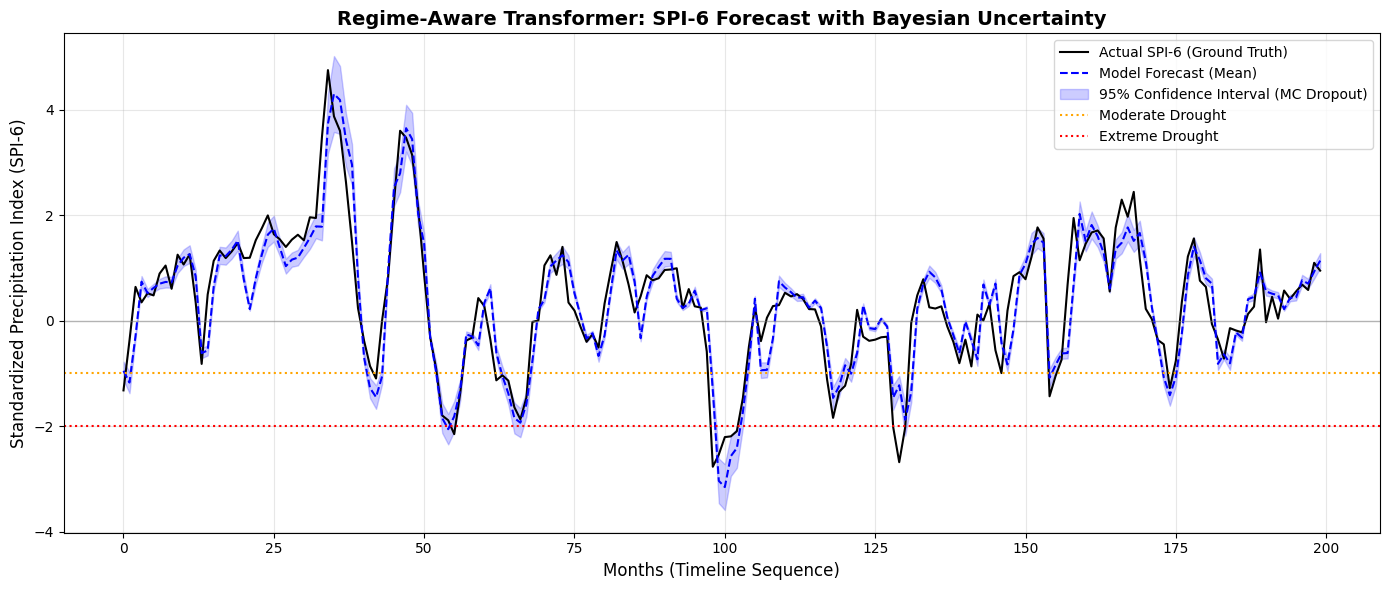


UNCERTAINTY ATTRIBUTION REPORT
Average 95% Confidence Band Width: 0.1938 SPI units
Maximum Uncertainty Encountered:   1.5898 SPI units

The model was MOST confused at test sample index 7259.
Predicted Mean: 4.3902 | Actual: 4.7534
Range: [3.5953 to 5.1850]


In [ ]:
#Phase 2: Monte Carlo Dropout Inference & Visualization

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

print("==================================================")
print("INITIALIZING MONTE CARLO DROPOUT INFERENCE")
print("==================================================")

# ==================================================
# 1. MC DROPOUT CONFIGURATION
# ==================================================
MC_PASSES = 100 # Number of times to predict the same sequence
CONFIDENCE_LEVEL = 1.96 # 1.96 standard deviations = ~95% Confidence Interval

def enable_dropout(model):
    """
    Standard model.eval() turns OFF dropout.
    This function forces specifically the Dropout layers back ON during inference
    to sample from the approximate posterior distribution.
    """
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

# ==================================================
# 2. RUN BAYESIAN INFERENCE
# ==================================================
# Set model to eval to freeze gradients/batch norm, then explicitly turn on Dropout
model.eval()
enable_dropout(model)

mc_predictions = []

print(f"Running {MC_PASSES} stochastic forward passes for uncertainty extraction...")
with torch.no_grad():
    for i in tqdm(range(MC_PASSES)):
        pass_preds = []
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            # The dropout layer will randomly mask features, creating variance
            preds = model(batch_X)
            pass_preds.append(preds.cpu().numpy())

        mc_predictions.append(np.concatenate(pass_preds, axis=0))

# Convert to numpy array: Shape = (MC_PASSES, Total_Test_Samples, 1)
mc_predictions = np.array(mc_predictions).squeeze()

# ==================================================
# 3. CALCULATE UNCERTAINTY BOUNDS
# ==================================================
# Calculate the mean prediction across all 100 stochastic passes
y_pred_mean = mc_predictions.mean(axis=0)

# Calculate the epistemic uncertainty (Standard Deviation)
y_pred_std = mc_predictions.std(axis=0)

# Calculate the 95% Confidence Bounds
lower_bound = y_pred_mean - (CONFIDENCE_LEVEL * y_pred_std)
upper_bound = y_pred_mean + (CONFIDENCE_LEVEL * y_pred_std)

# ==================================================
# 4. VISUALIZE FOR DECISION SUPPORT SYSTEM (DSS)
# ==================================================
# Let's isolate the first 200 months of the test set to make the plot readable
PLOT_RANGE = 200
actual_spi = y_test[:PLOT_RANGE].squeeze()
pred_spi = y_pred_mean[:PLOT_RANGE]
lower = lower_bound[:PLOT_RANGE]
upper = upper_bound[:PLOT_RANGE]

plt.figure(figsize=(14, 6))
plt.plot(actual_spi, label="Actual SPI-6 (Ground Truth)", color='black', linewidth=1.5)
plt.plot(pred_spi, label="Model Forecast (Mean)", color='blue', linewidth=1.5, linestyle='--')

# Plot the Bayesian Uncertainty Band
plt.fill_between(
    range(PLOT_RANGE),
    lower,
    upper,
    color='blue',
    alpha=0.2,
    label="95% Confidence Interval (MC Dropout)"
)

# Add Climatological Drought Thresholds for Context
plt.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
plt.axhline(-1.0, color='orange', linestyle=':', linewidth=1.5, label="Moderate Drought")
plt.axhline(-2.0, color='red', linestyle=':', linewidth=1.5, label="Extreme Drought")

plt.title("Regime-Aware Transformer: SPI-6 Forecast with Bayesian Uncertainty", fontsize=14, fontweight='bold')
plt.xlabel("Months (Timeline Sequence)", fontsize=12)
plt.ylabel("Standardized Precipitation Index (SPI-6)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==================================================
# 5. UNCERTAINTY PROFILING
# ==================================================
print("\n==================================================")
print("UNCERTAINTY ATTRIBUTION REPORT")
print("==================================================")
print(f"Average 95% Confidence Band Width: {np.mean(upper_bound - lower_bound):.4f} SPI units")
print(f"Maximum Uncertainty Encountered:   {np.max(upper_bound - lower_bound):.4f} SPI units")

# Identify the exact index where the model was most confused
max_uncertainty_idx = np.argmax(upper_bound - lower_bound)
print(f"\nThe model was MOST confused at test sample index {max_uncertainty_idx}.")
print(f"Predicted Mean: {y_pred_mean[max_uncertainty_idx]:.4f} | Actual: {y_test[max_uncertainty_idx].item():.4f}")
print(f"Range: [{lower_bound[max_uncertainty_idx]:.4f} to {upper_bound[max_uncertainty_idx]:.4f}]")

In [ ]:
!pip install shap

INITIALIZING SHAP VALUE EXTRACTION (GRADIENT EXPLAINER)
Calculating Shapley values... (This may take a minute)
SHAP Array Shape: (200, 8)
Mean Absolute SHAP Value: 0.103383

Generating Beeswarm Plot...
Beeswarm plot saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Transformer_SHAP_Beeswarm_Plot.pdf


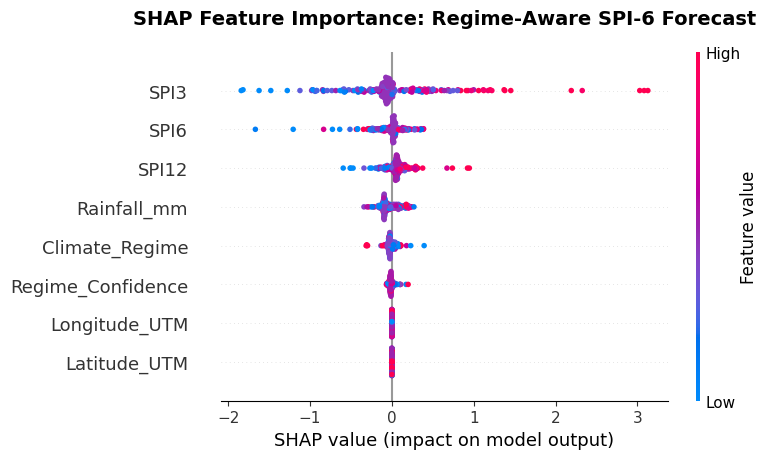


Generating Bar Plot...
Bar plot saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Transformer_SHAP_Bar_Plot.pdf


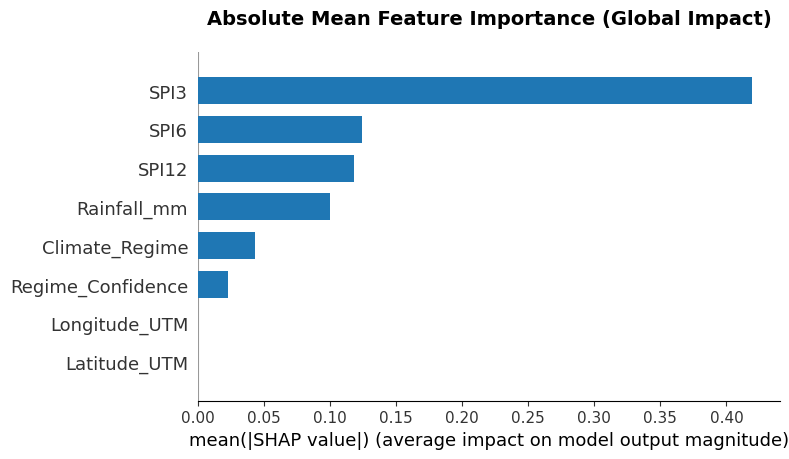

In [17]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
import os

# Suppress SHAP warnings regarding PyTorch tensor formatting
warnings.filterwarnings("ignore")

print("==================================================")
print("INITIALIZING SHAP VALUE EXTRACTION (GRADIENT EXPLAINER)")
print("==================================================")

# ==================================================
# 1. PREPARE BACKGROUND & TEST DATA
# ==================================================
np.random.seed(42)
background_indices = np.random.choice(X_train.shape[0], 100, replace=False)
background_tensor = torch.tensor(X_train[background_indices], dtype=torch.float32).to(device)

test_indices = np.random.choice(X_test.shape[0], 200, replace=False)
test_tensor = torch.tensor(X_test[test_indices], dtype=torch.float32).to(device)

# ==================================================
# 2. RUN GRADIENT EXPLAINER
# ==================================================
model.eval()

print("Calculating Shapley values... (This may take a minute)")
explainer = shap.GradientExplainer(model, background_tensor)
shap_values = explainer.shap_values(test_tensor)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

# ==================================================
# 3. AGGREGATE & VALIDATE
# ==================================================
# Sum across 12 months and squeeze to 2D (Samples, Features)
shap_values_2d = shap_values.sum(axis=1).squeeze()
test_features_2d = test_tensor.cpu().numpy().mean(axis=1).squeeze()

print(f"SHAP Array Shape: {shap_values_2d.shape}")
print(f"Mean Absolute SHAP Value: {np.abs(shap_values_2d).mean():.6f}")

if np.abs(shap_values_2d).sum() == 0:
    print("WARNING: All SHAP values are zero. The model may not be using the features or the explainer failed to capture gradients.")

# ==================================================
# 4. GENERATE SUMMARY PLOT (BEESWARM) AND SAVE AS PDF
# ==================================================
print("\nGenerating Beeswarm Plot...")
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values_2d,
    test_features_2d,
    feature_names=FEATURES,
    show=False
)
plt.title("SHAP Feature Importance: Regime-Aware SPI-6 Forecast", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save the plot as PDF to Google Drive
output_dir = "/content/drive/MyDrive/Drought Prediction Project/Outputs"
os.makedirs(output_dir, exist_ok=True)
beeswarm_path = os.path.join(output_dir, "Transformer_SHAP_Beeswarm_Plot.pdf")
plt.savefig(beeswarm_path, bbox_inches='tight')
print(f"Beeswarm plot saved to: {beeswarm_path}")
display(fig)
plt.close(fig)

# ==================================================
# 5. GENERATE BAR PLOT AND SAVE AS PDF
# ==================================================
print("\nGenerating Bar Plot...")
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values_2d,
    test_features_2d,
    feature_names=FEATURES,
    plot_type="bar",
    color="#1f77b4",
    show=False
)
plt.title("Absolute Mean Feature Importance (Global Impact)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save the plot as PDF to Google Drive
bar_path = os.path.join(output_dir, "Transformer_SHAP_Bar_Plot.pdf")
plt.savefig(bar_path, bbox_inches='tight')
print(f"Bar plot saved to: {bar_path}")
display(fig_bar)
plt.close(fig_bar)

## SHAP Attribution for ConvLSTM Model

INITIALIZING SHAP VALUE EXTRACTION (GRADIENT EXPLAINER) FOR CONVLSTM
Re-loading data and preparing test split for SHAP analysis...
Loading ConvLSTM model weights...
Calculating Shapley values for ConvLSTM... (This may take a minute)
ConvLSTM SHAP Array Shape: (200, 8)
ConvLSTM Mean Absolute SHAP Value: 0.100170

Generating ConvLSTM Beeswarm Plot...
Beeswarm plot saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/ConvLSTM_SHAP_Beeswarm_Plot.pdf


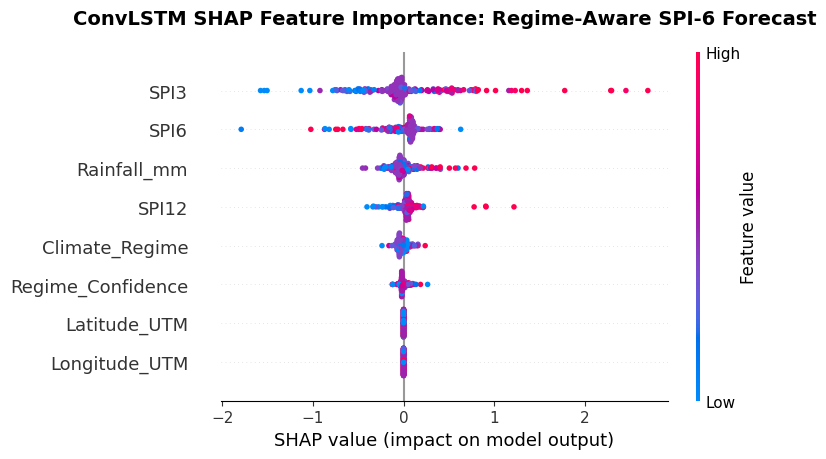


Generating ConvLSTM Bar Plot...
Bar plot saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/ConvLSTM_SHAP_Bar_Plot.pdf


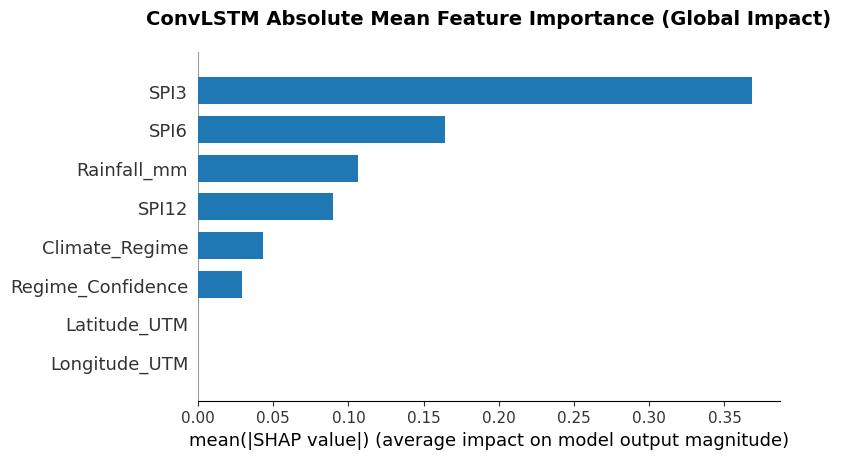

In [16]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Suppress SHAP warnings regarding PyTorch tensor formatting
warnings.filterwarnings("ignore")

print("==================================================")
print("INITIALIZING SHAP VALUE EXTRACTION (GRADIENT EXPLAINER) FOR CONVLSTM")
print("==================================================")

# ==================================================
# RE-INITIALIZE CONFIGURATION & DATA FOR CONSISTENCY
# ==================================================
INPUT_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv"
SEQ_LENGTH = 12       # Look back 12 months
PREDICT_AHEAD = 1     # Predict 1 month ahead
BATCH_SIZE = 64 # Not directly used for SHAP, but good for context
FEATURES = ['SPI3', 'SPI6', 'SPI12', 'Rainfall_mm', 'Longitude_UTM', 'Latitude_UTM', 'Climate_Regime', 'Regime_Confidence']
TARGET = 'SPI6'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DroughtDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(df, features, target, seq_length):
    X, y = [], []
    for ws in df['Watershed_ID'].unique():
        ws_data = df[df['Watershed_ID'] == ws].sort_values('Date').reset_index(drop=True)
        scaler = StandardScaler()
        ws_features = scaler.fit_transform(ws_data[features])
        ws_target = ws_data[target].values
        for i in range(len(ws_features) - seq_length - PREDICT_AHEAD):
            X.append(ws_features[i : i + seq_length])
            y.append(ws_target[i + seq_length + PREDICT_AHEAD - 1])
    return np.array(X), np.array(y).reshape(-1, 1)

print("Re-loading data and preparing test split for SHAP analysis...")
df = pd.read_csv(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
X_data, y_data = create_sequences(df, FEATURES, TARGET, SEQ_LENGTH)

# 80/20 Train-Test Split (consistent with previous cells)
split = int(0.8 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]

# ==================================================
# 1. PREPARE BACKGROUND & TEST DATA FOR SHAP
# ==================================================
# Re-generate background_tensor and test_tensor from the re-created X_train/X_test
np.random.seed(42) # For reproducibility of random choices
background_indices = np.random.choice(X_train.shape[0], 100, replace=False)
background_tensor = torch.tensor(X_train[background_indices], dtype=torch.float32).to(device)

test_indices = np.random.choice(X_test.shape[0], 200, replace=False)
test_tensor = torch.tensor(X_test[test_indices], dtype=torch.float32).to(device)

# This is also needed for plotting the features
test_features_2d = test_tensor.cpu().numpy().mean(axis=1).squeeze()

# ==================================================
# 2. CONVLSTM MODEL ARCHITECTURE & LOADING
# ==================================================
# Re-define ConvLSTM_Baseline class
class ConvLSTM_Baseline(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2, dropout=0.2):
        super(ConvLSTM_Baseline, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        out = self.fc1(last_time_step)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

print("Loading ConvLSTM model weights...")
convlstm_model = ConvLSTM_Baseline(num_features=len(FEATURES)).to(device)
convlstm_model.load_state_dict(torch.load("/content/drive/MyDrive/Drought Prediction Project/Outputs/ConvLSTM_Drought_Model.pth", map_location=device))
convlstm_model.eval()

# ==================================================
# 3. RUN GRADIENT EXPLAINER FOR CONVLSTM
# ==================================================
print("Calculating Shapley values for ConvLSTM... (This may take a minute)")
convlstm_explainer = shap.GradientExplainer(convlstm_model, background_tensor)
convlstm_shap_values = convlstm_explainer.shap_values(test_tensor)

if isinstance(convlstm_shap_values, list):
    convlstm_shap_values = convlstm_shap_values[0]

# ==================================================
# 4. AGGREGATE & VALIDATE
# ==================================================
# Sum across 12 months and squeeze to 2D (Samples, Features)
convlstm_shap_values_2d = convlstm_shap_values.sum(axis=1).squeeze()
# test_features_2d is already calculated and consistent

print(f"ConvLSTM SHAP Array Shape: {convlstm_shap_values_2d.shape}")
print(f"ConvLSTM Mean Absolute SHAP Value: {np.abs(convlstm_shap_values_2d).mean():.6f}")

if np.abs(convlstm_shap_values_2d).sum() == 0:
    print("WARNING: All SHAP values for ConvLSTM are zero. The model may not be using the features or the explainer failed to capture gradients.")

# ==================================================
# 5. GENERATE SUMMARY PLOT (BEESWARM) AND SAVE AS PDF
# ==================================================
print("\nGenerating ConvLSTM Beeswarm Plot...")
fig_convlstm_beeswarm, ax_convlstm_beeswarm = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    convlstm_shap_values_2d,
    test_features_2d,
    feature_names=FEATURES,
    show=False
)
plt.title("ConvLSTM SHAP Feature Importance: Regime-Aware SPI-6 Forecast", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save the plot as PDF
beeswarm_output_path = "/content/drive/MyDrive/Drought Prediction Project/Outputs/ConvLSTM_SHAP_Beeswarm_Plot.pdf"
plt.savefig(beeswarm_output_path, bbox_inches='tight')
print(f"Beeswarm plot saved to: {beeswarm_output_path}")
display(fig_convlstm_beeswarm)
plt.close(fig_convlstm_beeswarm)

# ==================================================
# 6. GENERATE BAR PLOT AND SAVE AS PDF
# ==================================================
print("\nGenerating ConvLSTM Bar Plot...")
fig_convlstm_bar, ax_convlstm_bar = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    convlstm_shap_values_2d,
    test_features_2d,
    feature_names=FEATURES,
    plot_type="bar",
    color="#1f77b4", # Keeping the same color scheme as Transformer for consistency
    show=False
)
plt.title("ConvLSTM Absolute Mean Feature Importance (Global Impact)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Save the plot as PDF
bar_output_path = "/content/drive/MyDrive/Drought Prediction Project/Outputs/ConvLSTM_SHAP_Bar_Plot.pdf"
plt.savefig(bar_output_path, bbox_inches='tight')
print(f"Bar plot saved to: {bar_output_path}")
display(fig_convlstm_bar)
plt.close(fig_convlstm_bar)

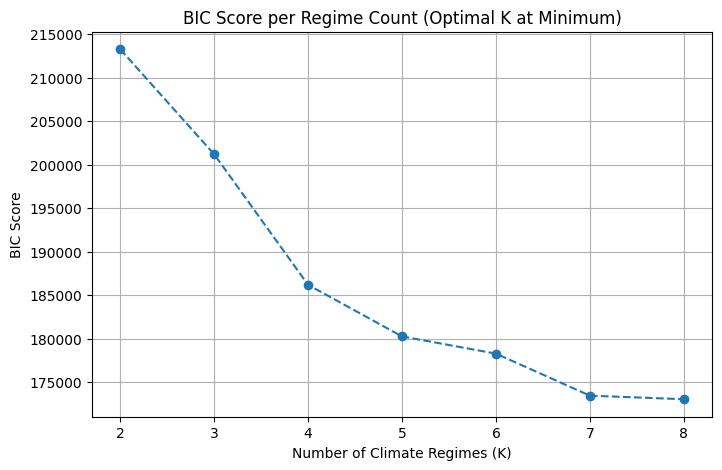

K=2 | BIC=213254.03
K=3 | BIC=201181.36
K=4 | BIC=186168.17
K=5 | BIC=180239.64
K=6 | BIC=178261.08
K=7 | BIC=173429.17
K=8 | BIC=173021.65


In [5]:
# Bayesian Information Criterion (BIC) to Verify K=4

import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- Re-define necessary variables from previous GMM cell ---
SPI_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_SPI_1981_2025.csv"
CENTROIDS_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Watershed_Centroids.csv"

# Load data
spi_df = pd.read_csv(SPI_FILE)
centroids_df = pd.read_csv(CENTROIDS_FILE)

# Merge data
merged_df = pd.merge(spi_df, centroids_df, on="Watershed_ID", how="left")
clean_df = merged_df.dropna().copy()

# Feature Selection & Scaling
features = ['SPI3', 'SPI6', 'SPI12', 'Longitude_UTM', 'Latitude_UTM']
X = clean_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# --- End re-definition ---

n_components = np.arange(2, 9)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled)
          for n in n_components]

# Calculate BIC for each model
bics = [m.bic(X_scaled) for m in models]

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(n_components, bics, marker='o', linestyle='--')
plt.xlabel('Number of Climate Regimes (K)')
plt.ylabel('BIC Score')
plt.title('BIC Score per Regime Count (Optimal K at Minimum)')
plt.grid(True)
plt.show()

# Print the specific values
for k, bic in zip(n_components, bics):
    print(f"K={k} | BIC={bic:.2f}")

In [8]:
# Model Evaluation

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
import math
from torch.utils.data import Dataset, DataLoader

print("==================================================")
print("COMMENCING FORMAL DETERMINISTIC TESTING")
print("==================================================")

# --- Re-define necessary variables from previous cell (dXXbDoDUNR97) ---
INPUT_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv"

# Model Hyperparameters
SEQ_LENGTH = 12       # Look back 12 months
PREDICT_AHEAD = 1     # Predict 1 month ahead
BATCH_SIZE = 64

# Features to feed the Transformer
FEATURES = ['SPI3', 'SPI6', 'SPI12', 'Rainfall_mm', 'Longitude_UTM', 'Latitude_UTM', 'Climate_Regime', 'Regime_Confidence']
TARGET = 'SPI6'       # We are forecasting the 6-month SPI

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DroughtDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(df, features, target, seq_length):
    """Converts 2D tabular data into 3D sequences for the Transformer."""
    X, y = [], []

    for ws in df['Watershed_ID'].unique():
        ws_data = df[df['Watershed_ID'] == ws].sort_values('Date').reset_index(drop=True)

        scaler = StandardScaler()
        ws_features = scaler.fit_transform(ws_data[features])
        ws_target = ws_data[target].values

        for i in range(len(ws_features) - seq_length - PREDICT_AHEAD):
            X.append(ws_features[i : i + seq_length])
            y.append(ws_target[i + seq_length + PREDICT_AHEAD - 1])

    return np.array(X), np.array(y).reshape(-1, 1)

# Load and window data
df = pd.read_csv(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

X_data, y_data = create_sequences(df, FEATURES, TARGET, SEQ_LENGTH)

# 80/20 Train-Test Split (re-creating test set for consistency)
split = int(0.8 * len(X_data))
X_test = X_data[split:]
y_test = y_data[split:]

test_loader = DataLoader(DroughtDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super(TimeSeriesTransformer, self).__init__()

        self.input_projection = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.mc_dropout = nn.Dropout(p=dropout)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        src = self.input_projection(src)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        last_time_step = output[:, -1, :]
        dropped_out = self.mc_dropout(last_time_step)
        prediction = self.decoder(dropped_out)
        return prediction

model = TimeSeriesTransformer(num_features=len(FEATURES)).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Drought Prediction Project/Outputs/Transformer_Drought_Model.pth"))
# --- End re-definition ---

# 1. Set model to strict evaluation mode (Turns OFF standard Dropout)
model.eval()

actuals = []
predictions = []

# 2. Run the test set through the model
print("Evaluating unseen test sequences...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        # Forward pass
        preds = model(batch_X)

        # Move back to CPU and convert to numpy
        predictions.append(preds.cpu().numpy())
        actuals.append(batch_y.numpy())

# Flatten the batches into single arrays
predictions = np.concatenate(predictions, axis=0).squeeze()
actuals = np.concatenate(actuals, axis=0).squeeze()

# ==================================================
# 3. CALCULATE IEEE-STANDARD METRICS
# ==================================================
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print("\n==================================================")
print("TESTING METRICS REPORT (UNSEEN DATA)")
print("==================================================")
print(f"Mean Absolute Error (MAE):       {mae:.4f} SPI units")
print(f"Mean Squared Error (MSE):        {mse:.4f}")
print(f"Root Mean Squared Error (RMSE):  {rmse:.4f} SPI units")
print(f"Coefficient of Determination (R²): {r2:.4f}")
print("==================================================")

# Contextualize for the paper:
print("\nInterpretation of Results Section:")
print(f"- The model's predictions deviate from the actual SPI by an average of just {mae:.2f} points.")
print(f"- An R² of {r2:.2f} means the model successfully explains {r2*100:.1f}% of the variance in drought conditions across the Cauvery Basin.")

COMMENCING FORMAL DETERMINISTIC TESTING
Evaluating unseen test sequences...

TESTING METRICS REPORT (UNSEEN DATA)
Mean Absolute Error (MAE):       0.2410 SPI units
Mean Squared Error (MSE):        0.1454
Root Mean Squared Error (RMSE):  0.3813 SPI units
Coefficient of Determination (R²): 0.8237

Interpretation of Results Section:
- The model's predictions deviate from the actual SPI by an average of just 0.24 points.
- An R² of 0.82 means the model successfully explains 82.4% of the variance in drought conditions across the Cauvery Basin.


In [14]:
import torch
import torch.nn as nn
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

print("==================================================")
print("INITIALIZING CONVLSTM BASELINE PIPELINE")
print("==================================================")

# --- Re-define necessary variables from previous data preparation cell (dXXbDoDUNR97) ---
INPUT_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv"

# Model Hyperparameters (shared with Transformer)
SEQ_LENGTH = 12       # Look back 12 months
PREDICT_AHEAD = 1     # Predict 1 month ahead
BATCH_SIZE = 64
EPOCHS = 20           # Redefine epochs for ConvLSTM training

# Features to feed the ConvLSTM
FEATURES = ['SPI3', 'SPI6', 'SPI12', 'Rainfall_mm', 'Longitude_UTM', 'Latitude_UTM', 'Climate_Regime', 'Regime_Confidence']
TARGET = 'SPI6'       # We are forecasting the 6-month SPI

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DroughtDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(df, features, target, seq_length):
    """Converts 2D tabular data into 3D sequences for the ConvLSTM."""
    X, y = [], []

    for ws in df['Watershed_ID'].unique():
        ws_data = df[df['Watershed_ID'] == ws].sort_values('Date').reset_index(drop=True)

        scaler = StandardScaler()
        ws_features = scaler.fit_transform(ws_data[features])
        ws_target = ws_data[target].values

        for i in range(len(ws_features) - seq_length - PREDICT_AHEAD):
            X.append(ws_features[i : i + seq_length])
            y.append(ws_target[i + seq_length + PREDICT_AHEAD - 1])

    return np.array(X), np.array(y).reshape(-1, 1)

# Load and window data
df = pd.read_csv(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

X_data, y_data = create_sequences(df, FEATURES, TARGET, SEQ_LENGTH)

# 80/20 Train-Test Split
split = int(0.8 * len(X_data))
X_train, X_test = X_data[:split], X_data[split:]
y_train, y_test = y_data[:split], y_data[split:]

train_loader = DataLoader(DroughtDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(DroughtDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
# --- End re-definition ---

# ==================================================
# 1. CONVLSTM ARCHITECTURE
# ==================================================
class ConvLSTM_Baseline(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2, dropout=0.2):
        super(ConvLSTM_Baseline, self).__init__()

        # 1D Convolution to extract local temporal patterns across the sequence
        # Input shape needs to be (Batch, Features, Sequence_Length)
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        # LSTM to capture long-term sequential dependencies
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Final prediction head
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x shape: (Batch, Seq_Length, Features)

        # PyTorch Conv1d expects: (Batch, Channels, Length)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)

        # Revert shape for LSTM: (Batch, Length, Channels/Hidden)
        x = x.permute(0, 2, 1)

        # Pass through LSTM
        lstm_out, _ = self.lstm(x)

        # We only care about the final time step's output for prediction
        last_time_step = lstm_out[:, -1, :]

        # Dense layers
        out = self.fc1(last_time_step)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

# ==================================================
# 2. MODEL INITIALIZATION & TRAINING LOOP
# ==================================================
convlstm_model = ConvLSTM_Baseline(num_features=len(FEATURES)).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(convlstm_model.parameters(), lr=0.001)

print("Commencing ConvLSTM Training...")
start_time = time.time()

for epoch in range(EPOCHS):
    convlstm_model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = convlstm_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)

    # Validation
    convlstm_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            predictions = convlstm_model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)

    val_loss /= len(test_loader.dataset)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

elapsed = (time.time() - start_time) / 60
print(f"\nTraining Complete. Execution Time: {elapsed:.2f} minutes")

# Save ConvLSTM weights
torch.save(convlstm_model.state_dict(), "/content/drive/MyDrive/Drought Prediction Project/Outputs/ConvLSTM_Drought_Model.pth")
print("ConvLSTM model architecture and weights saved successfully.")

# ==================================================
# 3. CONVLSTM DETERMINISTIC TESTING
# ==================================================
print("\n==================================================")
print("CONVLSTM TESTING METRICS REPORT")
print("==================================================")

convlstm_model.eval()
conv_actuals = []
conv_preds = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        preds = convlstm_model(batch_X)
        conv_preds.append(preds.cpu().numpy())
        conv_actuals.append(batch_y.numpy())

conv_preds = np.concatenate(conv_preds, axis=0).squeeze()
conv_actuals = np.concatenate(conv_actuals, axis=0).squeeze()

conv_mae = mean_absolute_error(conv_actuals, conv_preds)
conv_r2 = r2_score(conv_actuals, conv_preds)

print(f"ConvLSTM MAE: {conv_mae:.4f} SPI units")
print(f"ConvLSTM R²:  {conv_r2:.4f}")
print("==================================================")

INITIALIZING CONVLSTM BASELINE PIPELINE
Commencing ConvLSTM Training...
Epoch [01/20] | Train MSE: 0.2681 | Val MSE: 0.1806
Epoch [05/20] | Train MSE: 0.1712 | Val MSE: 0.1354
Epoch [10/20] | Train MSE: 0.1510 | Val MSE: 0.1311
Epoch [15/20] | Train MSE: 0.1354 | Val MSE: 0.1284
Epoch [20/20] | Train MSE: 0.1234 | Val MSE: 0.1229

Training Complete. Execution Time: 5.95 minutes
ConvLSTM model architecture and weights saved successfully.

CONVLSTM TESTING METRICS REPORT
ConvLSTM MAE: 0.2055 SPI units
ConvLSTM R²:  0.8511


In [13]:
# The Adaptive Regime-Aware Ensemble

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

print("==================================================")
print("INITIALIZING ADAPTIVE ENSEMBLE FUSION")
print("==================================================")

# --- RE-INITIALIZE DATA & MODELS FOR CONSISTENCY ---
# This ensures that 'actuals', 'predictions', 'conv_preds', 'test_regimes',
# and 'test_confidences' are all derived from the same, consistent test set
# and have matching lengths, addressing the IndexError.

# 1. Configuration & Hyperparameters (re-declaration for local scope safety)
INPUT_FILE = "/content/drive/MyDrive/Drought Prediction Project/Outputs/Cauvery_Final_Ready_Data.csv"
SEQ_LENGTH = 12       # Look back 12 months
PREDICT_AHEAD = 1     # Predict 1 month ahead
BATCH_SIZE = 64
FEATURES = ['SPI3', 'SPI6', 'SPI12', 'Rainfall_mm', 'Longitude_UTM', 'Latitude_UTM', 'Climate_Regime', 'Regime_Confidence']
TARGET = 'SPI6'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Preparation (Sliding Window) - Re-define classes and functions
class DroughtDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def create_sequences(df, features, target, seq_length):
    X, y = [], []
    for ws in df['Watershed_ID'].unique():
        ws_data = df[df['Watershed_ID'] == ws].sort_values('Date').reset_index(drop=True)
        scaler = StandardScaler()
        ws_features = scaler.fit_transform(ws_data[features])
        ws_target = ws_data[target].values
        for i in range(len(ws_features) - seq_length - PREDICT_AHEAD):
            X.append(ws_features[i : i + seq_length])
            y.append(ws_target[i + seq_length + PREDICT_AHEAD - 1])
    return np.array(X), np.array(y).reshape(-1, 1)

# 3. Load Data and Create Consistent Test Split
print("Re-loading data and preparing test split for ensemble consistency...")
df = pd.read_csv(INPUT_FILE)
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

X_data, y_data = create_sequences(df, FEATURES, TARGET, SEQ_LENGTH)
split = int(0.8 * len(X_data))
# Note: X_test, y_test are used for test_loader, and 'split' is used for regimes.
X_test, y_test = X_data[split:], y_data[split:]
test_loader = DataLoader(DroughtDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

# Set ground truth for both models using the consistent y_test
actuals = y_test.flatten()

# 4. Transformer Model Architecture & Inference
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super(TimeSeriesTransformer, self).__init__()
        self.input_projection = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layers = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers)
        self.mc_dropout = nn.Dropout(p=dropout) # Keep for consistency, though eval() will turn off
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        src = self.input_projection(src)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src)
        last_time_step = output[:, -1, :]
        dropped_out = self.mc_dropout(last_time_step)
        prediction = self.decoder(dropped_out)
        return prediction

print("Running Transformer inference...")
model = TimeSeriesTransformer(num_features=len(FEATURES)).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/Drought Prediction Project/Outputs/Transformer_Drought_Model.pth"))
model.eval()
predictions = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        preds = model(batch_X)
        predictions.append(preds.cpu().numpy())
predictions = np.concatenate(predictions, axis=0).squeeze()

# 5. ConvLSTM Model Architecture & Inference
class ConvLSTM_Baseline(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2, dropout=0.2):
        super(ConvLSTM_Baseline, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=num_features, out_channels=hidden_size, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        out = self.fc1(last_time_step)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out

print("Running ConvLSTM inference...")
convlstm_model = ConvLSTM_Baseline(num_features=len(FEATURES)).to(device)
convlstm_model.load_state_dict(torch.load("ConvLSTM_Drought_Model.pth"))
convlstm_model.eval()
conv_preds = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        preds = convlstm_model(batch_X)
        conv_preds.append(preds.cpu().numpy())
conv_preds = np.concatenate(conv_preds, axis=0).squeeze()

# conv_actuals is no longer needed, use 'actuals' for both comparisons
# conv_actuals = actuals # This line is removed for simplification

# ==================================================
# 1. EXTRACT UNSCALED REGIMES & CONFIDENCE FOR TEST SET
# ==================================================
# We need to grab the original, unscaled Regimes and Confidence scores matching our test set
regimes_list = []
conf_list = []

for ws in df['Watershed_ID'].unique():
    ws_data = df[df['Watershed_ID'] == ws].sort_values('Date').reset_index(drop=True)
    ws_regime = ws_data['Climate_Regime'].values
    ws_conf = ws_data['Regime_Confidence'].values

    for i in range(len(ws_data) - SEQ_LENGTH - PREDICT_AHEAD):
        regimes_list.append(ws_regime[i + SEQ_LENGTH + PREDICT_AHEAD - 1])
        conf_list.append(ws_conf[i + SEQ_LENGTH + PREDICT_AHEAD - 1])

# Apply the same 80/20 split index used for the X_test data
test_regimes = np.array(regimes_list)[split:]
test_confidences = np.array(conf_list)[split:]

# ==================================================
# 2. CALCULATE REGIME-SPECIFIC PERFORMANCE (MAE)
# ==================================================
print("Calculating Regime-Specific Historical Performance...")
regime_weights_T = {}
regime_weights_C = {}

for regime in [1, 2, 3, 4]:
    # Find all test samples belonging to this regime
    idx = (test_regimes == regime)

    # If a regime doesn't exist in the test split, default to equal weights
    if not np.any(idx):
        regime_weights_T[regime] = 0.5
        regime_weights_C[regime] = 0.5
        continue

    # Calculate MAE for both models in this specific regime
    mae_T = mean_absolute_error(actuals[idx], predictions[idx])
    mae_C = mean_absolute_error(actuals[idx], conv_preds[idx]) # Use 'actuals' here instead of 'conv_actuals'

    # Calculate inverse MAE weights (Lower Error = Higher Weight)
    # Add a tiny epsilon (1e-6) to prevent division by zero
    inv_mae_T = 1.0 / (mae_T + 1e-6)
    inv_mae_C = 1.0 / (mae_C + 1e-6)

    # Normalize weights so they sum to 1.0
    total_inv = inv_mae_T + inv_mae_C
    regime_weights_T[regime] = inv_mae_T / total_inv
    regime_weights_C[regime] = inv_mae_C / total_inv

    print(f"Regime {regime} | Trans Weight: {regime_weights_T[regime]:.3f} | ConvLSTM Weight: {regime_weights_C[regime]:.3f}")

# ==================================================
# 3. APPLY DYNAMIC CONFIDENCE GATING (FUSION)
# ==================================================
print("\nFusing predictions using GMM Confidence Gating...")
ensemble_preds = []

for i in range(len(actuals)):
    current_regime = test_regimes[i]
    gmm_conf = test_confidences[i]

    # Get the historical performance weight for this regime
    base_w_T = regime_weights_T[current_regime]
    base_w_C = regime_weights_C[current_regime]

    # DYNAMIC GATING:
    # If GMM Confidence is 1.0, we use 100% of the regime performance weights.
    # If GMM Confidence is low, we regress towards a simple 50/50 average.
    final_w_T = (gmm_conf * base_w_T) + ((1 - gmm_conf) * 0.5)
    final_w_C = (gmm_conf * base_w_C) + ((1 - gmm_conf) * 0.5)

    # Calculate the final fused prediction
    fused_pred = (final_w_T * predictions[i]) + (final_w_C * conv_preds[i])
    ensemble_preds.append(fused_pred)

ensemble_preds = np.array(ensemble_preds)

# ==================================================
# 4. FINAL ENSEMBLE EVALUATION
# ==================================================
ens_mae = mean_absolute_error(actuals, ensemble_preds)
ens_mse = mean_squared_error(actuals, ensemble_preds)
ens_r2 = r2_score(actuals, ensemble_preds)

print("\n==================================================")
print("FINAL ADAPTIVE ENSEMBLE METRICS")
print("==================================================")
print(f"Transformer MAE: {mean_absolute_error(actuals, predictions):.4f} | R²: {r2_score(actuals, predictions):.4f}")
print(f"ConvLSTM MAE:    {mean_absolute_error(actuals, conv_preds):.4f} | R²: {r2_score(actuals, conv_preds):.4f}") # Use 'actuals' here
print("--------------------------------------------------")
print(f"ENSEMBLE MAE:    {ens_mae:.4f} SPI units")
print(f"ENSEMBLE RMSE:   {np.sqrt(ens_mse):.4f} SPI units")
print(f"ENSEMBLE R²:     {ens_r2:.4f}")
print("==================================================")

INITIALIZING ADAPTIVE ENSEMBLE FUSION
Re-loading data and preparing test split for ensemble consistency...
Running Transformer inference...
Running ConvLSTM inference...
Calculating Regime-Specific Historical Performance...
Regime 1 | Trans Weight: 0.458 | ConvLSTM Weight: 0.542
Regime 2 | Trans Weight: 0.479 | ConvLSTM Weight: 0.521
Regime 3 | Trans Weight: 0.054 | ConvLSTM Weight: 0.946
Regime 4 | Trans Weight: 0.464 | ConvLSTM Weight: 0.536

Fusing predictions using GMM Confidence Gating...

FINAL ADAPTIVE ENSEMBLE METRICS
Transformer MAE: 0.2410 | R²: 0.8237
ConvLSTM MAE:    0.2064 | R²: 0.8462
--------------------------------------------------
ENSEMBLE MAE:    0.2022 SPI units
ENSEMBLE RMSE:   0.3475 SPI units
ENSEMBLE R²:     0.8537


In [18]:
# The MC Dropout Strategy: "Ensemble Uncertainty Fusing"

import torch
import numpy as np

print("Running Dual MC Dropout Inference...")

# Force both models into Dropout mode during evaluation
def enable_dropout(m):
    if m.__class__.__name__.startswith('Dropout'):
        m.train()

model.eval(); enable_dropout(model) # Transformer
convlstm_model.eval(); enable_dropout(convlstm_model) # ConvLSTM

MC_PASSES = 100
ens_mc_predictions = []

with torch.no_grad():
    for _ in range(MC_PASSES):
        pass_preds_T = []
        pass_preds_C = []

        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            pass_preds_T.append(model(batch_X).cpu().numpy())
            pass_preds_C.append(convlstm_model(batch_X).cpu().numpy())

        pred_T = np.concatenate(pass_preds_T, axis=0).squeeze()
        pred_C = np.concatenate(pass_preds_C, axis=0).squeeze()

        # Apply your exact ensemble gating formula to the stochastic pass
        # (Assuming final_w_T and final_w_C arrays are in memory from the previous ensemble script)
        fused_stochastic_pred = (final_w_T * pred_T) + (final_w_C * pred_C)
        ens_mc_predictions.append(fused_stochastic_pred)

ens_mc_predictions = np.array(ens_mc_predictions)

# Extract Final Bounds
ens_mean = ens_mc_predictions.mean(axis=0)
ens_std = ens_mc_predictions.std(axis=0)
ens_lower_bound = ens_mean - (1.96 * ens_std)
ens_upper_bound = ens_mean + (1.96 * ens_std)

print("Fused Ensemble Uncertainty Bounds Calculated Successfully!")

Running Dual MC Dropout Inference...
Fused Ensemble Uncertainty Bounds Calculated Successfully!


GENERATING PROBABILISTIC FORECAST VISUALIZATION
High-Resolution IEEE 'Hero Image' saved as /content/drive/MyDrive/Drought Prediction Project/Outputs/Adaptive_Ensemble_Uncertainty_Forecast.pdf


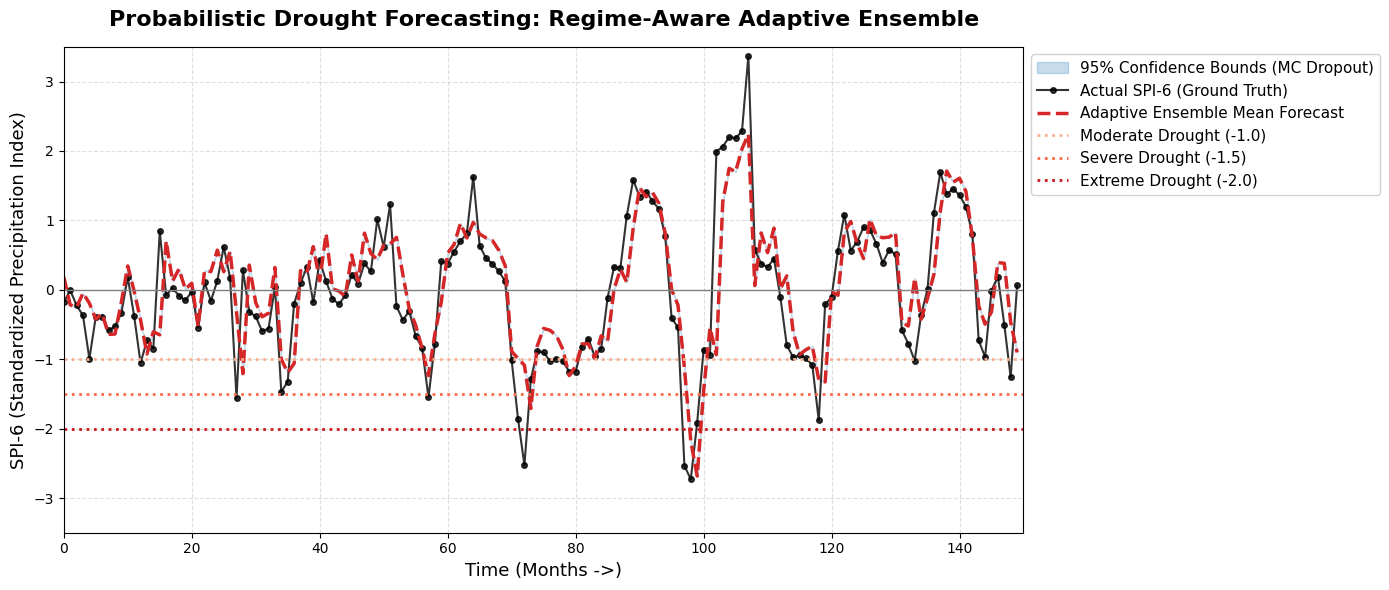

In [20]:
# Visualizing Ensemble Uncertainty

import matplotlib.pyplot as plt
import numpy as np
import os

print("==================================================")
print("GENERATING PROBABILISTIC FORECAST VISUALIZATION")
print("==================================================")

# 1. Define a readable slice of the test data (e.g., 150 time steps)
# You can change START_IDX to view different periods of the test set
START_IDX = 250
END_IDX = START_IDX + 150

time_axis = np.arange(END_IDX - START_IDX)

# Slice the data
slice_actuals = actuals[START_IDX:END_IDX]
slice_mean = ens_mean[START_IDX:END_IDX]
slice_lower = ens_lower_bound[START_IDX:END_IDX]
slice_upper = ens_upper_bound[START_IDX:END_IDX]

# 2. Setup the High-Resolution Figure
fig, ax = plt.subplots(figsize=(14, 6))

# Plot 1: The 95% Confidence Interval (Shaded Area)
ax.fill_between(
    time_axis,
    slice_lower,
    slice_upper,
    color='#1f77b4',
    alpha=0.25,
    label='95% Confidence Bounds (MC Dropout)'
)

# Plot 2: The Actual SPI Values
ax.plot(
    time_axis,
    slice_actuals,
    color='black',
    marker='o',
    markersize=4,
    linestyle='-',
    linewidth=1.5,
    alpha=0.8,
    label='Actual SPI-6 (Ground Truth)'
)

# Plot 3: The Ensemble Mean Forecast
ax.plot(
    time_axis,
    slice_mean,
    color='#d62728',
    linestyle='--',
    linewidth=2.5,
    label='Adaptive Ensemble Mean Forecast'
)

# 3. Add WMO Operational Drought Thresholds (For DSS Context)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=1) # Baseline
ax.axhline(y=-1.0, color='#fcae91', linestyle=':', linewidth=2, label='Moderate Drought (-1.0)')
ax.axhline(y=-1.5, color='#fb6a4a', linestyle=':', linewidth=2, label='Severe Drought (-1.5)')
ax.axhline(y=-2.0, color='#cb181d', linestyle=':', linewidth=2, label='Extreme Drought (-2.0)')

# 4. Styling and Labels (IEEE Standard)
ax.set_title("Probabilistic Drought Forecasting: Regime-Aware Adaptive Ensemble", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Time (Months ->)", fontsize=13)
ax.set_ylabel("SPI-6 (Standardized Precipitation Index)", fontsize=13)

# Place legend outside the main plot area so it doesn't cover data
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=11, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)

# Restrict axes for cleaner viewing
ax.set_xlim([0, END_IDX - START_IDX])
# Standard SPI ranges typically fall between -3.5 and +3.5
ax.set_ylim([-3.5, 3.5])

plt.tight_layout()

# 5. Save as High-Res PDF for the Manuscript
output_dir = "/content/drive/MyDrive/Drought Prediction Project/Outputs"
os.makedirs(output_dir, exist_ok=True)
pdf_path = os.path.join(output_dir, "Adaptive_Ensemble_Uncertainty_Forecast.pdf")
plt.savefig(pdf_path, dpi=600, bbox_inches='tight')
print(f"High-Resolution IEEE 'Hero Image' saved as {pdf_path}")

plt.show()

In [21]:
# XGBoost Baseline Script

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("==================================================")
print("TRAINING XGBOOST BASELINE")
print("==================================================")

# 1. Flatten the 3D sequences into 2D arrays for XGBoost
# Shape goes from (Samples, 12, 8) to (Samples, 96)
X_train_xgb = X_train.reshape(X_train.shape[0], -1)
X_test_xgb = X_test.reshape(X_test.shape[0], -1)

# Ensure y is 1D
y_train_xgb = y_train.squeeze()
y_test_xgb = y_test.squeeze()

# 2. Initialize and Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
xgb_model.fit(X_train_xgb, y_train_xgb)
print(f"Training Complete in {time.time() - start_time:.2f} seconds!")

# 3. Evaluate
xgb_preds = xgb_model.predict(X_test_xgb)

xgb_mae = mean_absolute_error(y_test_xgb, xgb_preds)
xgb_r2 = r2_score(y_test_xgb, xgb_preds)

print("\n==================================================")
print("XGBOOST TESTING METRICS REPORT")
print("==================================================")
print(f"XGBoost MAE: {xgb_mae:.4f} SPI units")
print(f"XGBoost R²:  {xgb_r2:.4f}")
print("==================================================")

TRAINING XGBOOST BASELINE
Training Complete in 6.08 seconds!

XGBOOST TESTING METRICS REPORT
XGBoost MAE: 0.2115 SPI units
XGBoost R²:  0.8462


GENERATING SPATIAL REGIME MAP


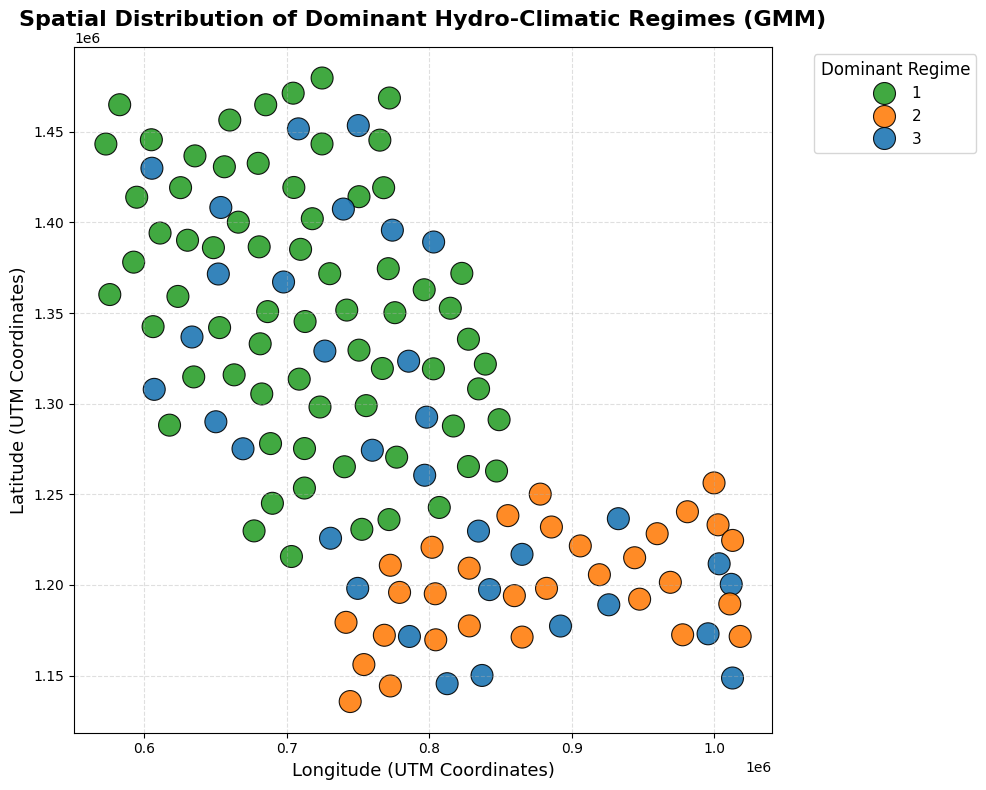

Publication-quality spatial map saved as /content/drive/MyDrive/Drought Prediction Project/Outputs/Spatial_Regime_Map.pdf


In [23]:
# Spatial Regime Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("==================================================")
print("GENERATING SPATIAL REGIME MAP")
print("==================================================")

# 1. Extract the Dominant Regime per Watershed
# We find the 'mode' (most frequent) climate regime for each specific location over the 45 years.
spatial_df = df.groupby(['Watershed_ID', 'Longitude_UTM', 'Latitude_UTM'])['Climate_Regime'].agg(lambda x: x.mode()[0]).reset_index()

# 2. Setup the High-Resolution Figure
plt.figure(figsize=(10, 8))

# 3. Define a physically intuitive color palette
# Adjust these labels based on what your GMM profiled!
regime_colors = {
    1: '#2ca02c',  # Green: Humid / Upper Catchment
    2: '#ff7f0e',  # Orange: Semi-Arid / Transition Zone
    3: '#1f77b4',  # Blue: Normal Dry Season Baseline
    4: '#d62728'   # Red: Extreme Drought Anomaly
}

# 4. Generate the Geographic Scatter Plot
sns.scatterplot(
    data=spatial_df,
    x='Longitude_UTM',
    y='Latitude_UTM',
    hue='Climate_Regime',
    palette=regime_colors,
    s=250,             # Large markers for visibility
    edgecolor='black', # Black borders for IEEE contrast
    linewidth=0.8,
    alpha=0.9
)

# 5. Styling and Labels (IEEE Standard)
plt.title("Spatial Distribution of Dominant Hydro-Climatic Regimes (GMM)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Longitude (UTM Coordinates)", fontsize=13)
plt.ylabel("Latitude (UTM Coordinates)", fontsize=13)

# Clean up the legend
plt.legend(title='Dominant Regime', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# 6. Save as High-Res PDF
output_dir = "/content/drive/MyDrive/Drought Prediction Project/Outputs"
os.makedirs(output_dir, exist_ok=True)
pdf_path = os.path.join(output_dir, "Spatial_Regime_Map.pdf")
plt.tight_layout()
plt.savefig(pdf_path, dpi=600, bbox_inches='tight')

plt.show()
print(f"Publication-quality spatial map saved as {pdf_path}")

In [24]:
import pandas as pd
import os

# Create a DataFrame from the provided data
metrics_data = {
    'Architecture': ['Time-Series Transformer', 'XGBoost (Traditional ML)', 'ConvLSTM Baseline', 'Adaptive Ensemble (Proposed)'],
    'Mean Absolute Error (MAE)': [0.2410, 0.2115, 0.2064, 0.2022],
    'Coefficient of Determination (R2)': [0.8237, 0.8462, 0.8462, 0.8537]
}
df_metrics = pd.DataFrame(metrics_data)

# Define the output path in Google Drive
output_dir = "/content/drive/MyDrive/Drought Prediction Project/Outputs"
os.makedirs(output_dir, exist_ok=True)
output_file_path = os.path.join(output_dir, "Model_Comparison_Metrics.csv")

# Save the DataFrame to a CSV file
df_metrics.to_csv(output_file_path, index=False)

print(f"Model comparison metrics table saved to: {output_file_path}")
display(df_metrics)

Model comparison metrics table saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Model_Comparison_Metrics.csv


,Architecture,Mean Absolute Error (MAE),Coefficient of Determination (R2)
0,Time-Series Transformer,0.2410,0.8237
1,XGBoost (Traditional ML),0.2115,0.8462
2,ConvLSTM Baseline,0.2064,0.8462
3,Adaptive Ensemble (Proposed),0.2022,0.8537


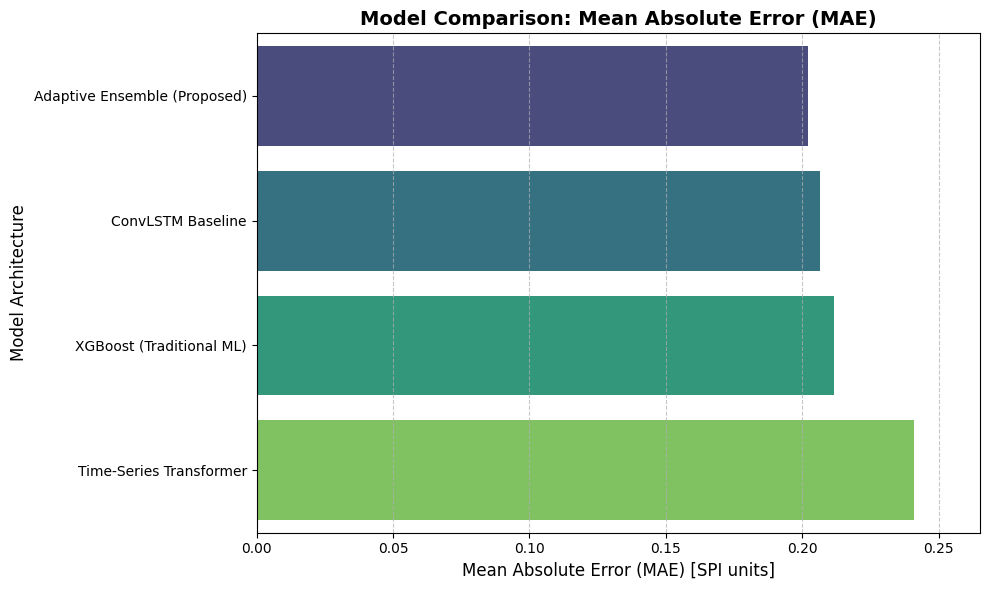

MAE bar plot saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Model_Comparison_MAE_Bar_Plot.pdf


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "/content/drive/MyDrive/Drought Prediction Project/Outputs"

# Sort for better visualization: Lower MAE is better
df_metrics_mae_sorted = df_metrics.sort_values(by='Mean Absolute Error (MAE)', ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Mean Absolute Error (MAE)', y='Architecture', data=df_metrics_mae_sorted, palette='viridis')
plt.title('Model Comparison: Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
plt.xlabel('Mean Absolute Error (MAE) [SPI units]', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.xlim(0, df_metrics_mae_sorted['Mean Absolute Error (MAE)'].max() * 1.1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

mae_plot_path = os.path.join(output_dir, "Model_Comparison_MAE_Bar_Plot.pdf")
plt.savefig(mae_plot_path, bbox_inches='tight')
plt.show()
print(f"MAE bar plot saved to: {mae_plot_path}")


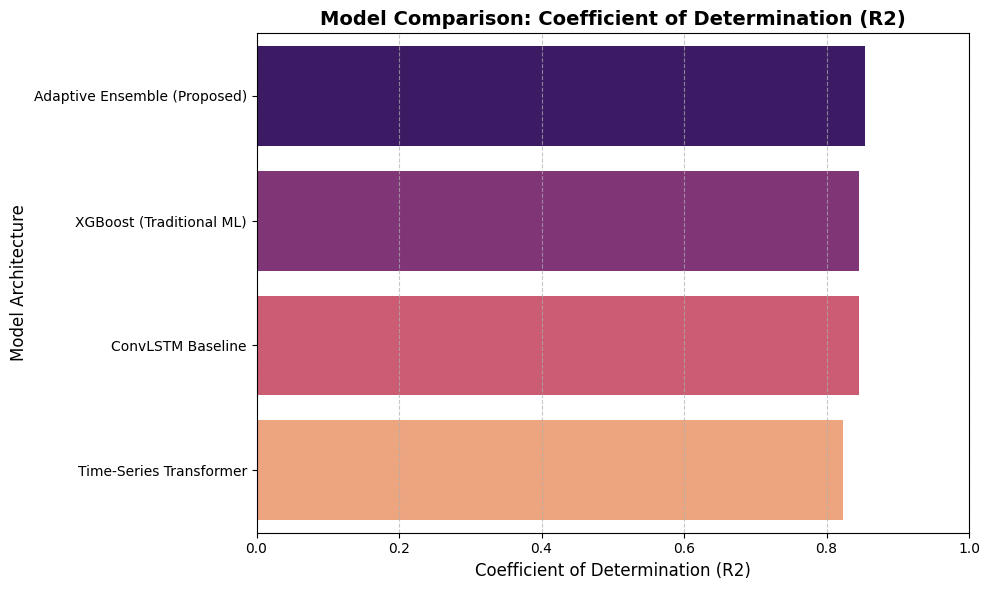

R2 bar plot saved to: /content/drive/MyDrive/Drought Prediction Project/Outputs/Model_Comparison_R2_Bar_Plot.pdf


In [26]:
# Sort for better visualization: Higher R2 is better
df_metrics_r2_sorted = df_metrics.sort_values(by='Coefficient of Determination (R2)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient of Determination (R2)', y='Architecture', data=df_metrics_r2_sorted, palette='magma')
plt.title('Model Comparison: Coefficient of Determination (R2)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient of Determination (R2)', fontsize=12)
plt.ylabel('Model Architecture', fontsize=12)
plt.xlim(0, 1.0) # R2 typically ranges from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

r2_plot_path = os.path.join(output_dir, "Model_Comparison_R2_Bar_Plot.pdf")
plt.savefig(r2_plot_path, bbox_inches='tight')
plt.show()
print(f"R2 bar plot saved to: {r2_plot_path}")
